# NICE на Swiss roll в 2D

Короткая демонстрация на PyTorch: обучим обратимое преобразование двумерного Swiss roll в стандартную нормаль, вычислим точную плотность модели и сгенерируем новые точки.

**Запуск:** Python 3.10+, Jupyter / Colab → **Run all**. Данные создаются на месте. По умолчанию выбирается CUDA, если она доступна, иначе CPU. В следующей ячейке можно явно задать `DEVICE = "cpu"` или `DEVICE = "cuda:0"` (либо другой номер GPU). Если библиотек нет, раскомментируйте первую строку следующей ячейки.

In [76]:
# %pip install torch numpy matplotlib
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import tqdm
from typing import Callable
from importlib import reload

SEED, STEPS, BATCH_SIZE = 42, 4000, 256
NOISE = 0.06  # Шум в координатах после деления на 10.
DEVICE = "cpu"  # "auto", "cpu", "cuda:0", "cuda:1", ...
if DEVICE == "auto":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = torch.device(DEVICE)
if device.type == "cuda" and not torch.cuda.is_available():
    raise RuntimeError('CUDA недоступна: выберите DEVICE = "cpu" или "auto".')
torch.manual_seed(SEED)
torch.set_num_threads(2)  # Для маленьких MLP на CPU.
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
device_name = torch.cuda.get_device_name(device) if device.type == "cuda" else "CPU"
if (torch.xpu.is_available() and device_name == "CPU"):
    device_name = torch.xpu.get_device_name(0)
print(f"PyTorch {torch.__version__} | {device} ({device_name}) | seed={SEED}")

PyTorch 2.14.1+cpu | cpu (CPU) | seed=42


## 1. Двумерный Swiss roll

Используем спираль — проекцию обычного 3D Swiss roll на плоскость $(X,Z)$:

$$t\sim U(1.5\pi,4.5\pi),\qquad
x=\frac1{10}(t\cos t,\ t\sin t)+\varepsilon,\quad
\varepsilon\sim\mathcal N(0,\sigma^2 I_2).$$

Шум $\sigma=0.06$ превращает одномерную кривую в полноценную двумерную плотность.
Обучающая и проверочная выборки независимы. Цвет по $t$ нужен только для графиков; модель получает две координаты $x$.

In [19]:
def make_swissroll(n):
    t = rng.uniform(1.5 * np.pi, 4.5 * np.pi, n)
    x = np.column_stack([t * np.cos(t), t * np.sin(t)]) / 10
    x += rng.normal(scale=NOISE, size=x.shape)
    return torch.tensor(x, dtype=torch.float32, device=device), t

x_train, _ = make_swissroll(6000)
x_val, t_val = make_swissroll(2000)

## 2. Обратимые слои

В аддитивном coupling-слое $y_1=x_1$, $y_2=x_2+m_\theta(x_1)$.
Обратный ход: $x_2=y_2-m_\theta(y_1)$, поэтому обращать MLP не нужно.
Якобиан треугольный с единицами на диагонали: $\det J=1$.
Чередуем неизменяемую координату в восьми слоях и добавляем обучаемый масштаб:

$$z=f_\theta(x)=e^s\odot g_\theta(x),\qquad
\log|\det J_f(x)|=s_1+s_2.$$

При $p_Z=\mathcal N(0,I_2)$ формула замены переменных даёт

$$\log p_\theta(x)=-\tfrac12\sum_{j=1}^2(z_j^2+\log 2\pi)+\sum_{j=1}^2s_j.$$

Минимизируем среднюю **NLL**: $-\log p_\theta(x)$; единицы — нат на точку.

In [84]:
import model
from model import logprop, loss_function
reload(model)

<module 'model' from '/home/alekseyka/projects/science school/model.py'>

In [85]:
midModel = (lambda in_width, out_width: nn.Sequential(
    nn.Linear(in_width, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, out_width)
))

model = model.NICE(midModel).to(device)

## 3. Обучение максимальным правдоподобием

Adam обновляет MLP и общий масштаб. Проверочная выборка используется только для наблюдения за качеством. Сравним NLL до и после обучения: меньше — лучше.

tensor([-2.1935], grad_fn=<MulBackward0>)


100%|██████████| 4000/4000 [00:33<00:00, 121.06it/s]


[(0, 2.1935324668884277, 2.0826714038848877), (100, 2.107412099838257, 2.1284379959106445), (200, 2.4061360359191895, 2.0266385078430176), (300, 3.117860794067383, 2.16430926322937), (400, 2.013193130493164, 2.3237144947052), (500, 2.730299949645996, 3.610031843185425), (600, 3.3268439769744873, 3.4243109226226807), (700, 2.162740707397461, 2.5119543075561523), (800, 2.7706968784332275, 2.6027886867523193), (900, 2.8785929679870605, 2.9382004737854004), (1000, 3.030346393585205, 3.3616490364074707), (1100, 1.9908009767532349, 4.598158836364746), (1200, 2.442845582962036, 3.4179751873016357), (1300, 3.702608108520508, 6.406728744506836), (1400, 3.167255401611328, 4.789687156677246), (1500, 2.096431016921997, 2.7422382831573486), (1600, 3.321880340576172, 4.301250457763672), (1700, 3.0406510829925537, 2.584444999694824), (1800, 2.2841334342956543, 5.0632452964782715), (1900, 2.4192426204681396, 2.9950320720672607), (2000, 3.1957950592041016, 4.031100749969482), (2100, 3.6216745376586914,

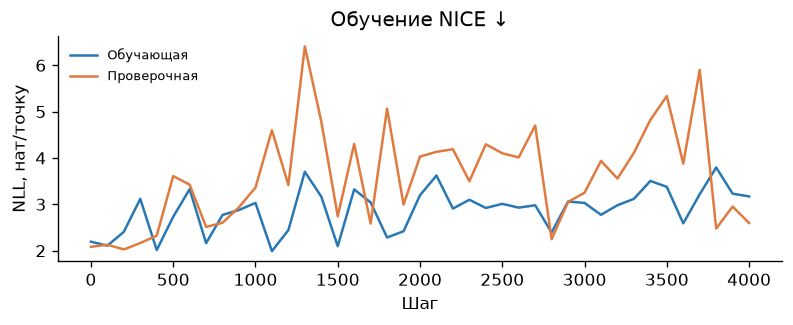

In [86]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []

print(logprop(model(x_train[0:1])))

@torch.no_grad()
def record(step):
    history.append((step, -logprop(model(x_train[0:1])).item(),
                         -logprop(model(x_val[0:1])).item()))

record(0)
if device.type == "cuda":
    torch.cuda.synchronize(device)  # CUDA асинхронна: ждём перед замером времени.
started = time.perf_counter()
model.train()
for step in tqdm.tqdm(range(1, STEPS + 1)):
    batch = x_train[torch.randint(len(x_train), (BATCH_SIZE,), device=x_train.device)]
    optimizer.zero_grad()
    loss = loss_function(model(batch), model.jacobian_det())
    # print(loss.shape)
    loss.backward()
    optimizer.step()
    if step % 100 == 0 or step == STEPS:
        record(step)
model.eval()
if device.type == "cuda":
    torch.cuda.synchronize(device)

print(history)

print(f"Обучение: {time.perf_counter() - started:.1f} с; {STEPS} шагов")
print(f"NLL (val): {history[0][2]:.3f} -> {history[-1][2]:.3f} нат/точку")

h = np.array(history)
fig, ax = plt.subplots(figsize=(6.5, 2.6), layout="constrained")
ax.plot(h[:, 0], h[:, 1], label="Обучающая", color="#2878B5")
ax.plot(h[:, 0], h[:, 2], label="Проверочная", color="#E07A3F")
ax.set(xlabel="Шаг", ylabel="NLL, нат/точку", title="Обучение NICE ↓")
ax.legend(frameon=False, fontsize=8)
plt.show()

## 4. Данные → нормаль → новые точки

Слева — проверочные данные и контуры **обученной плотности**.
В центре — те же точки после $f_\theta$; окружности показывают уровни стандартной нормали.
Справа — генерация: $z\sim\mathcal N(0,I_2)$, $x=f_\theta^{-1}(z)$.
Цвет в первых двух панелях соответствует параметру $t$ и помогает проследить перенос точек.

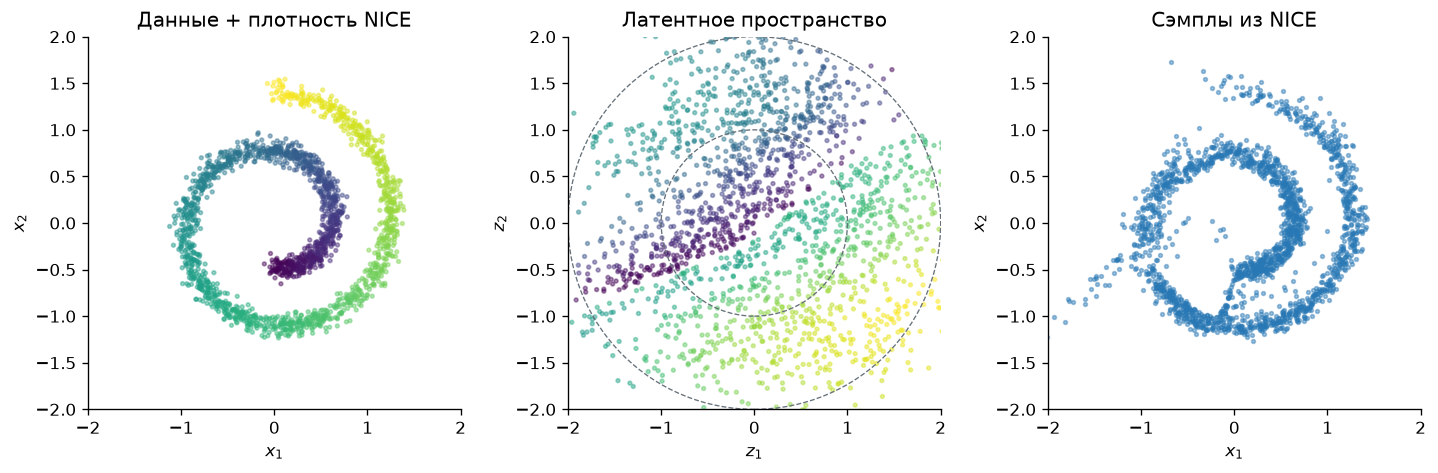

In [88]:
extent = 2
z_extent = 2
with torch.no_grad():
    z_val = model(x_val)
    generated = model.inverse(torch.randn(2000, 2))
    # Общие границы включают все точки, в том числе хвосты генерации.
    # extent = max(1.8, x_val.abs().max().item(), generated.abs().max().item()) + 0.1
    # z_extent = max(3.5, z_val.abs().max().item()) + 0.1
    gx, gy = np.meshgrid(np.linspace(-extent, extent, 180),
                         np.linspace(-extent, extent, 180))
    grid = torch.tensor(np.column_stack([gx.ravel(), gy.ravel()]),
                        dtype=x_val.dtype, device=device)
    density = logprop(model(grid)).exp().cpu().numpy().reshape(gx.shape)


# Matplotlib работает с CPU-массивами: перед numpy() переносим тензоры через .cpu().
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), layout="constrained")
colors = t_val
axes[0].scatter(*x_val.T.cpu().numpy(), c=colors, cmap="viridis", s=5, alpha=0.45)
axes[1].scatter(*z_val.T.cpu().numpy(), c=colors, cmap="viridis", s=5, alpha=0.45)
for radius in (1, 2, 3):
    axes[1].add_patch(plt.Circle((0, 0), radius, fill=False,
                                color="#67727B", ls="--", lw=0.8))
axes[2].scatter(*generated.T.cpu().numpy(), c="#2878B5", s=5, alpha=0.45)
for ax, title in zip(axes, ["Данные + плотность NICE", "Латентное пространство",
                           "Сэмплы из NICE"]):
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
for ax in (axes[0], axes[2]):
    ax.set(xlim=(-extent, extent), ylim=(-extent, extent), xlabel="$x_1$", ylabel="$x_2$")
axes[1].set(xlim=(-z_extent, z_extent), ylim=(-z_extent, z_extent), xlabel="$z_1$", ylabel="$z_2$")
plt.show()

## 5. Численные проверки

Проверяем оба направления обращения и сравниваем аналитический log-det с определителем полного $2\times2$ якобиана, вычисленного autograd. Float64 уменьшает погрешность этой проверки; обучение выше шло в float32.

In [6]:
from copy import deepcopy
check_model = deepcopy(model).double()
x_check = x_val[:32].double()
z_check = torch.randn(32, 2, dtype=torch.float64, device=device)
with torch.no_grad():
    x_error = (check_model.inverse(check_model(x_check)[0]) - x_check).abs().max()
    z_error = (check_model(check_model.inverse(z_check))[0] - z_check).abs().max()

errors = []
for point in x_check[:5]:
    jac = torch.autograd.functional.jacobian(
        lambda p: check_model(p[None])[0][0], point)
    numeric = torch.linalg.slogdet(jac).logabsdet
    errors.append((numeric - check_model.log_scale.sum()).abs().item())

assert x_error < 1e-8 and z_error < 1e-8
assert max(errors) < 1e-8
assert np.isfinite(h).all() and history[-1][2] < history[0][2]
print(f"max |inverse(forward(x)) - x| = {x_error:.2e}")
print(f"max |forward(inverse(z)) - z| = {z_error:.2e}")
print(f"max ошибка log-det = {max(errors):.2e}")
print("Все проверки пройдены.")

max |inverse(forward(x)) - x| = 1.33e-15
max |forward(inverse(z)) - z| = 2.00e-15
max ошибка log-det = 2.40e-14
Все проверки пройдены.


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

def data_loader():
    return torch.utils.data.DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True)

loader = data_loader()

### Что заметить

- Сравните форму данных и генерации, NLL и остаточную структуру в латентном облаке. Окружности в центре — ориентир, а не тест нормальности.
- Coupling-слои сохраняют площадь; финальный масштаб меняет её **глобально**, поэтому log-det не зависит от точки. Это ограничение NICE: на спирали возможны перемычки между витками и неполное совпадение плотностей.
- Обратимость подтверждает реализацию, но сама по себе не гарантирует хорошего обучения.

**Мини-эксперимент:** поменяйте `NOISE` на `0.03` или `0.10` и запустите все ячейки заново. Чем тоньше спираль, тем сложнее её моделировать. Можно также увеличить `STEPS`.

Источник: Dinh, Krueger, Bengio, [NICE: Non-linear Independent Components Estimation](https://arxiv.org/abs/1410.8516), разделы 2–3. Здесь — компактный учебный пример с гауссовой базой.